<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/04_sustax_extreme_analysis_heatmaps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [7]:
from google.colab import drive
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")

BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")
PHASE_B_FOLDER = os.path.join(SUSTAX_DIR, "PHASE_B_SCENARIOS")
OUT_FIG_FOLDER = os.path.join(PHASE_B_FOLDER, "FIGURES_PHASE_B")
OUT_FIG_FOLDER_SSP = os.path.join(PHASE_B_FOLDER, "FIGURES_PHASE_B_SSP_ONLY")

os.makedirs(OUT_FIG_FOLDER, exist_ok=True)
os.makedirs(OUT_FIG_FOLDER_SSP, exist_ok=True)

TARGET_DATE = "2015-10-23"
TARGET_DT = pd.Timestamp(TARGET_DATE)

PREFERRED_SCENARIOS = ["ERA5", "SSP245", "SSP370", "SSP585"]

SCENARIO_COLORS = {
    "ERA5":   "#1f77b4",
    "SSP245": "#2ca02c",
    "SSP370": "#d62728",
    "SSP585": "#9467bd",
    "SSP119": "#17becf",
    "SSP126": "#8c564b",
    "SSP343": "#ff7f0e",
    "SSP434": "#bcbd22",
    "SSP460": "#7f7f7f",
}

POINTS_TO_USE = [
    "Sustax_ Manzanillo_LosReyesTotal",
    "Sustax_ManzanilloTotal",
    "Sustax_MinatitlanTotal",
    "Sustax_TecomanTotal",
    "Sustax_TolimanTotal",
    "Sustax_Veladero_de_OtatesTotal",
    "Sustax_VilladeAlvarezTotal",
    "Sustax_Zapotitlan_de_VadilloTotal",
]

SSP_LIST = ["SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

print("PROJECT_DIR:", PROJECT_DIR)
print("BYSCEN_TOTAL_FOLDER:", BYSCEN_TOTAL_FOLDER)
print("PHASE_B_FOLDER:", PHASE_B_FOLDER)
print("OUT_FIG_FOLDER:", OUT_FIG_FOLDER)
print("OUT_FIG_FOLDER_SSP:", OUT_FIG_FOLDER_SSP)

pd.DataFrame({
    "item": ["PROJECT_DIR", "BYSCEN_TOTAL_FOLDER", "PHASE_B_FOLDER", "OUT_FIG_FOLDER", "OUT_FIG_FOLDER_SSP"],
    "path": [PROJECT_DIR, BYSCEN_TOTAL_FOLDER, PHASE_B_FOLDER, OUT_FIG_FOLDER, OUT_FIG_FOLDER_SSP]
}).head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación
BYSCEN_TOTAL_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_TOTAL_MERGED/BY_SCENARIO_TOTAL
PHASE_B_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS
OUT_FIG_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B
OUT_FIG_FOLDER_SSP: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B_SSP_ONLY


,item,path
0,PROJECT_DIR,/content/drive/MyDrive/Doctorado /Probabilidad...
1,BYSCEN_TOTAL_FOLDER,/content/drive/MyDrive/Doctorado /Probabilidad...
2,PHASE_B_FOLDER,/content/drive/MyDrive/Doctorado /Probabilidad...
3,OUT_FIG_FOLDER,/content/drive/MyDrive/Doctorado /Probabilidad...
4,OUT_FIG_FOLDER_SSP,/content/drive/MyDrive/Doctorado /Probabilidad...


# **Cargar tablas base y helpers**

In [8]:
df_daily = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_daily_extended.csv"))
df_monthly_daily = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_monthly_daily.csv"))
df_weekly = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_weekly.csv"))
df_combined = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_combined.csv"))

def normalize_date_series(s):
    d0 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    dt = d1 if d1.notna().sum() > d0.notna().sum() else d0
    return dt.dt.normalize()

def pick_precip_col(df):
    meta_cols = {"sustax_total", "lat", "lon", "date"}
    candidates = [c for c in df.columns if c not in meta_cols]

    for c in candidates:
        cl = c.lower()
        if ("tp" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        cl = c.lower()
        if ("pr" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        if "precip" in c.lower():
            return c

    if len(candidates) == 1:
        return candidates[0]

    raise ValueError(f"No pude identificar columna de precipitación en {df.columns.tolist()}")

def get_available_scenarios_for_point(sustax_total, folder):
    files = glob.glob(os.path.join(folder, f"{sustax_total}__*.csv"))
    scenarios = []
    for fp in files:
        name = os.path.basename(fp).replace(".csv", "")
        parts = name.split("__")
        if len(parts) >= 2 and "summary" not in name.lower():
            scenarios.append(parts[1])
    return sorted(list(set(scenarios)))

def get_scenario_file(sustax_total, scenario, folder):
    pattern = os.path.join(folder, f"{sustax_total}__{scenario}*.csv")
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None

def compute_monthly_max_weekly(df, value_col=None):
    out = df.copy()
    out["date"] = normalize_date_series(out["date"])
    out = out.dropna(subset=["date"]).copy()

    if value_col is None:
        value_col = pick_precip_col(out)

    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.sort_values("date").reset_index(drop=True)

    out["weekly_accum_7d_mm"] = out[value_col].rolling(window=7, min_periods=7).sum()
    out["year_month"] = out["date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        out.groupby("year_month")["weekly_accum_7d_mm"]
        .max()
        .reset_index()
        .rename(columns={"weekly_accum_7d_mm": "monthly_max_weekly_mm"})
    )
    return out, monthly

def choose_scenarios_for_plot(sustax_total):
    available = get_available_scenarios_for_point(sustax_total, BYSCEN_TOTAL_FOLDER)

    chosen = []
    for sc in PREFERRED_SCENARIOS:
        if sc in available:
            chosen.append(sc)

    if len(chosen) < 4:
        for sc in available:
            if sc not in chosen:
                chosen.append(sc)
            if len(chosen) >= 4:
                break

    return chosen[:4]

print("df_daily:", df_daily.shape)
print("df_monthly_daily:", df_monthly_daily.shape)
print("df_weekly:", df_weekly.shape)
print("df_combined:", df_combined.shape)

display(df_combined.head())
print("Columnas df_combined:")
print(df_combined.columns.tolist())

df_daily: (75, 6)
df_monthly_daily: (75, 6)
df_weekly: (75, 7)
df_combined: (75, 15)


,sustax_total,scenario,event_value_daily_mm,daily_percentile_full_series,daily_rank_full_series,n_days_full_series,monthly_max_daily_2015_10_mm,october_percentile_daily_max,october_rank_daily_max,n_october_years_daily_max,event_value_weekly_7d_mm,monthly_max_weekly_2015_10_mm,october_percentile_weekly_max,october_rank_weekly_max,n_october_years_weekly_max
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,0.343163,62.054434,23119,37256,13.985031,73.529412,75,102,4.617921,106.399573,88.235294,90,102
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,0.892510,68.405089,25485,37256,6.900040,65.686275,67,102,9.837805,29.988042,20.588235,21,102
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,0.275105,61.514924,22918,37256,4.003961,27.450980,28,102,7.462686,43.745216,56.862745,58,102
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,0.712683,66.730191,24861,37256,9.115235,63.725490,65,102,9.453609,370.535151,100.000000,102,102
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,10.515098,91.120893,33948,37256,22.831460,47.058824,48,102,18.270972,58.979454,20.588235,21,102


Columnas df_combined:
['sustax_total', 'scenario', 'event_value_daily_mm', 'daily_percentile_full_series', 'daily_rank_full_series', 'n_days_full_series', 'monthly_max_daily_2015_10_mm', 'october_percentile_daily_max', 'october_rank_daily_max', 'n_october_years_daily_max', 'event_value_weekly_7d_mm', 'monthly_max_weekly_2015_10_mm', 'october_percentile_weekly_max', 'october_rank_weekly_max', 'n_october_years_weekly_max']


# **Validación visual de extremos y comparación diario vs semanal**

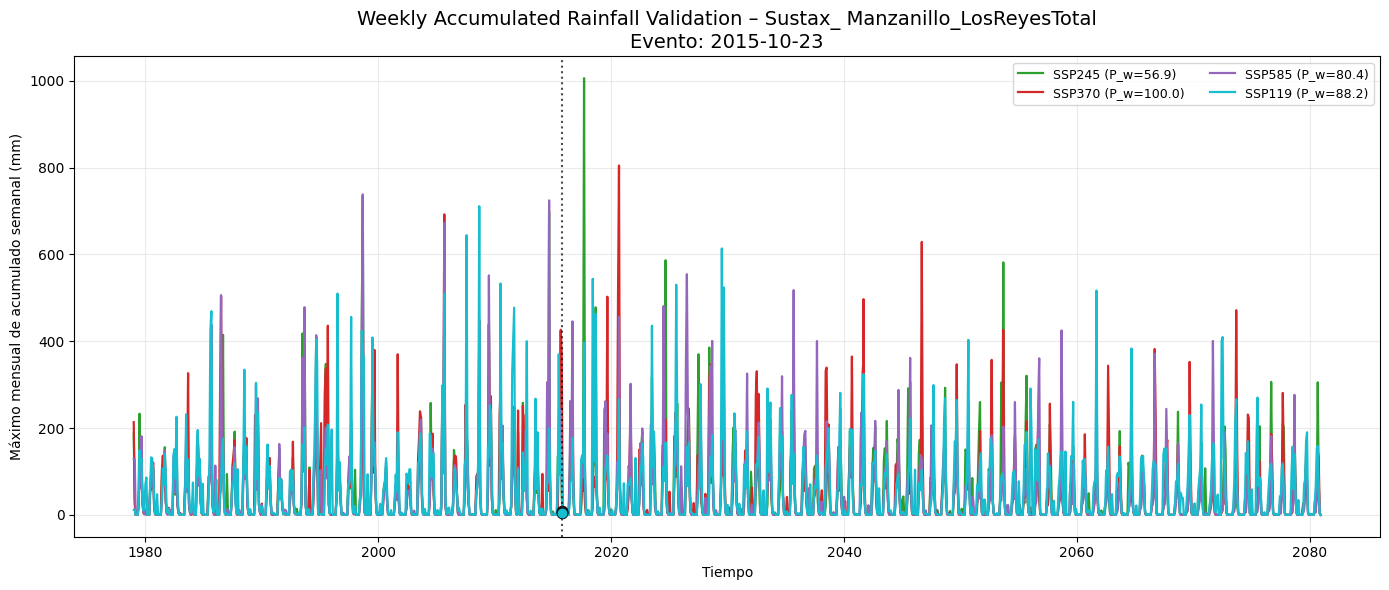

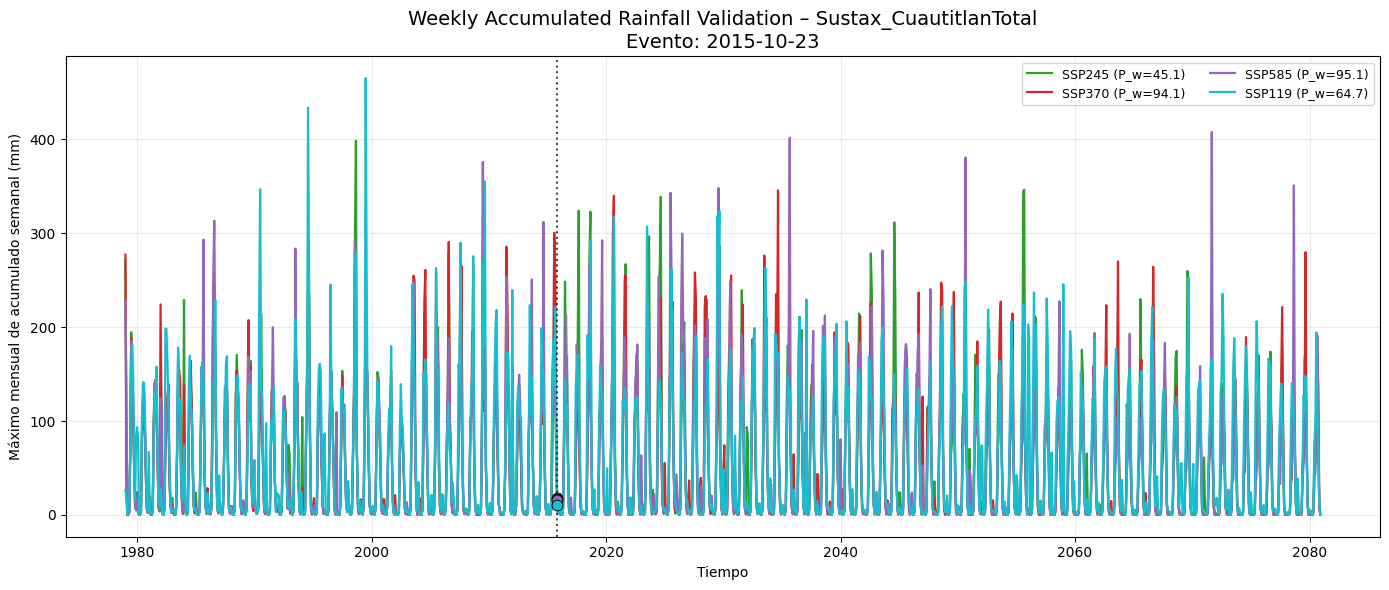

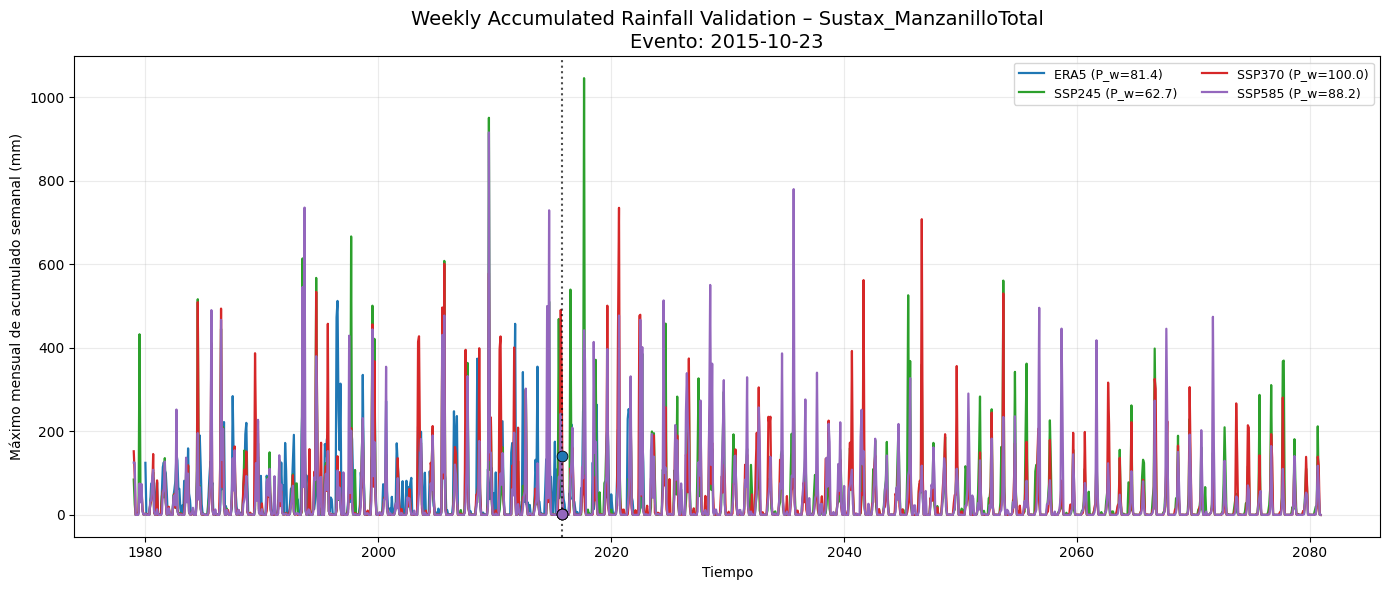

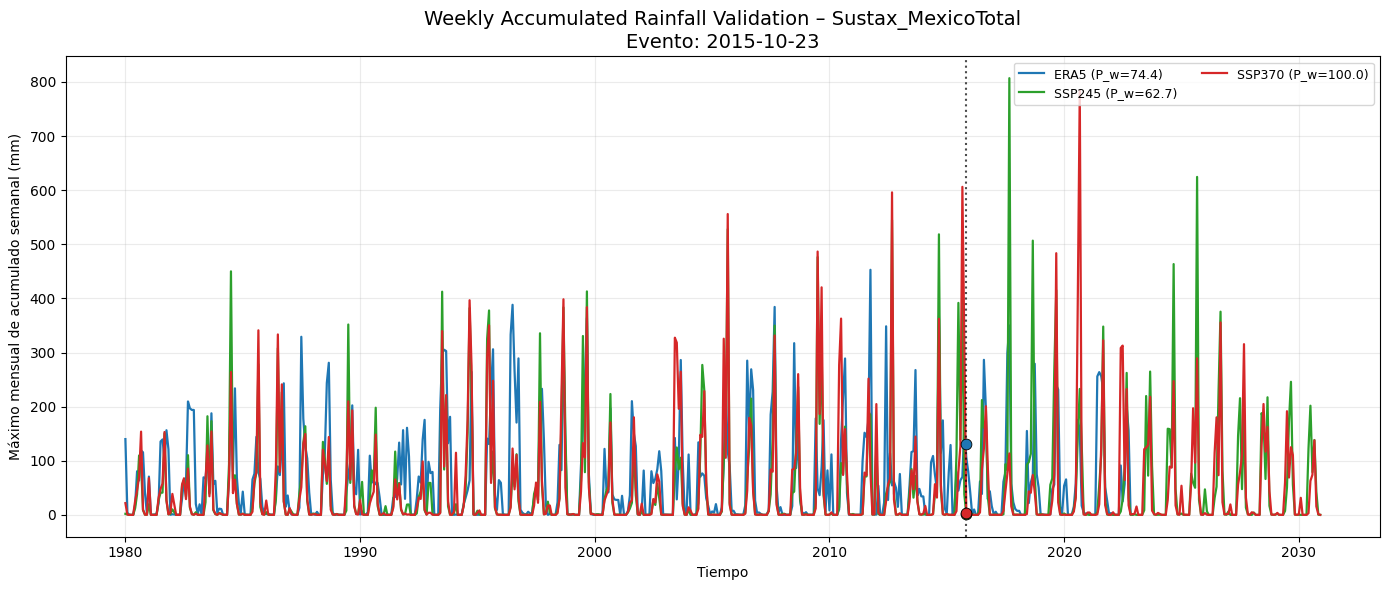

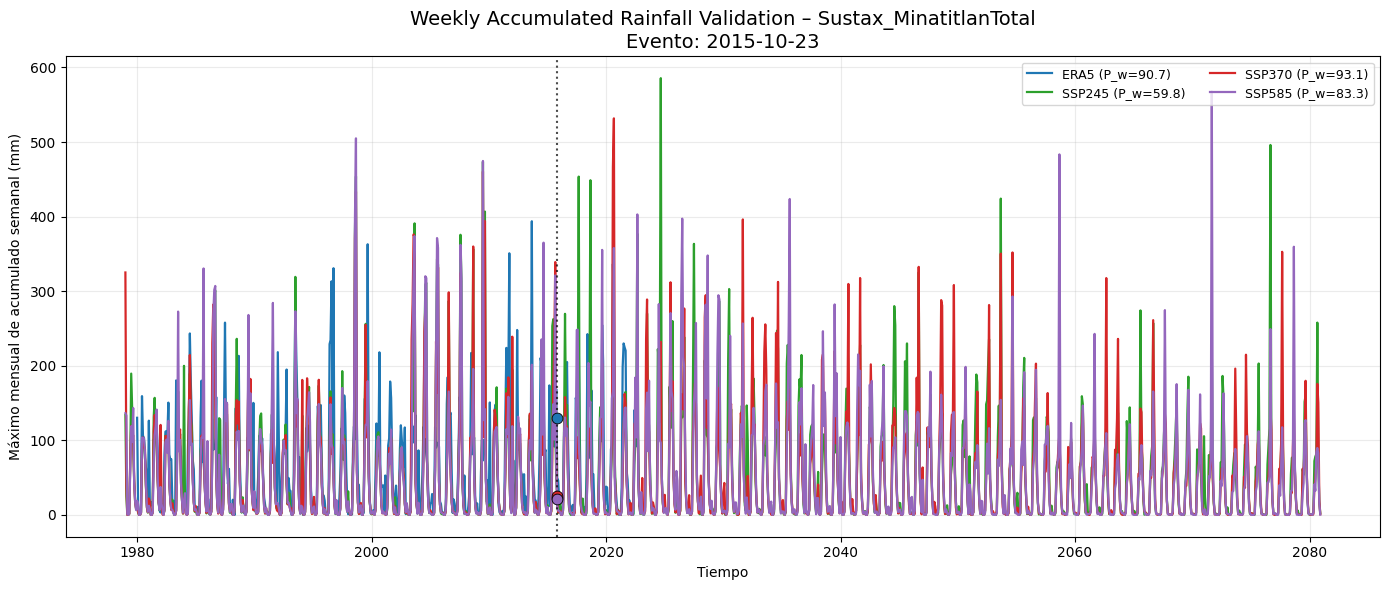

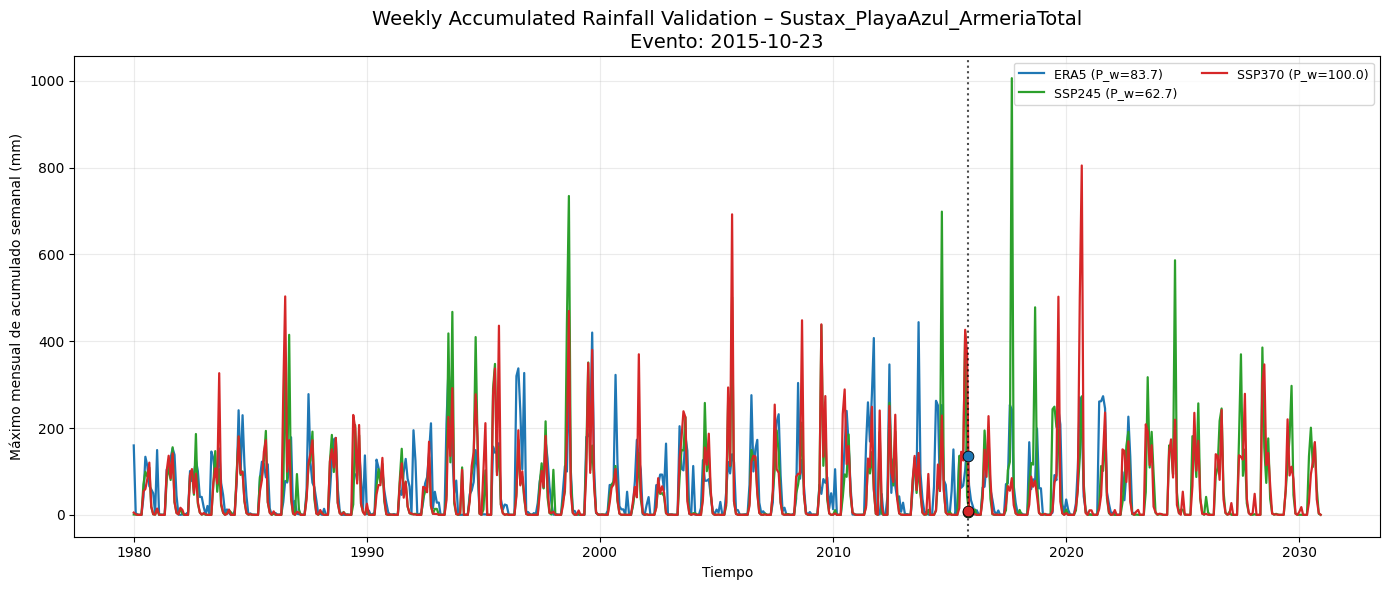

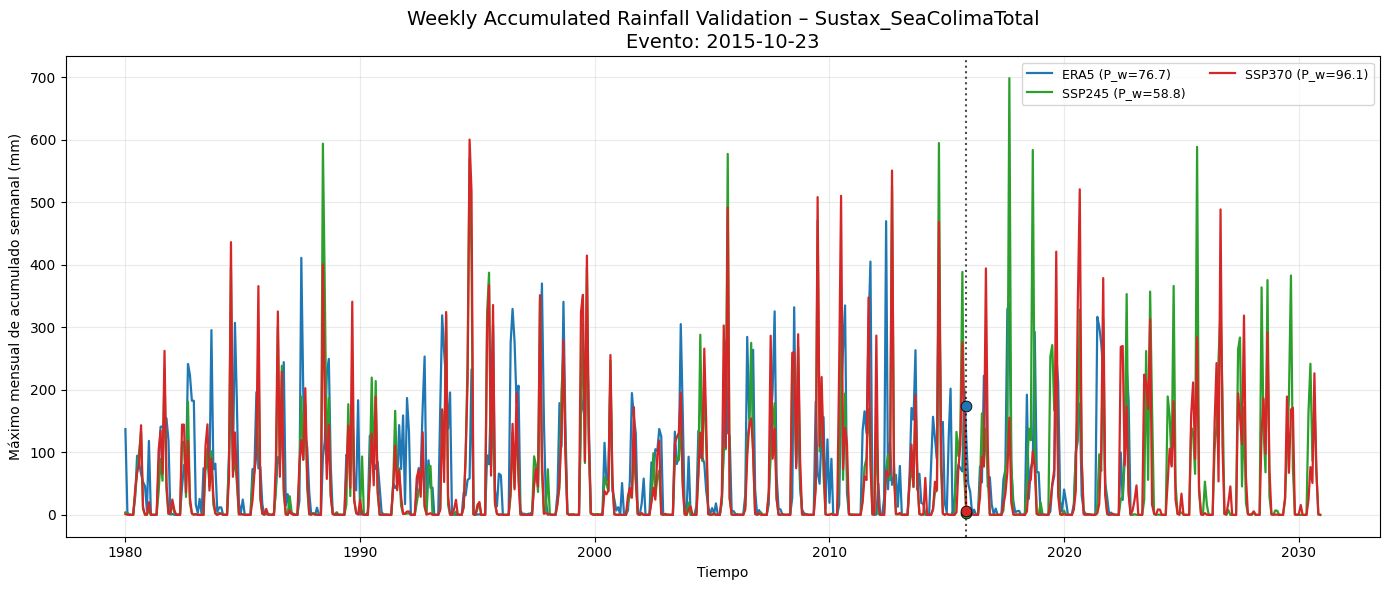

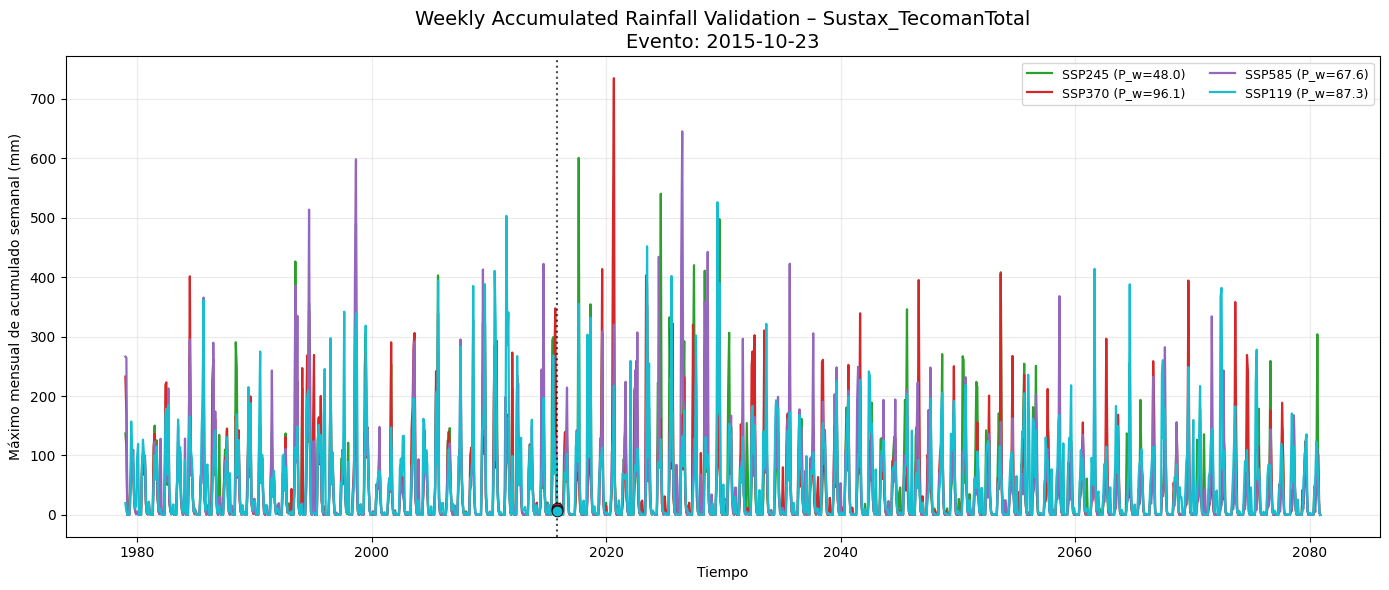

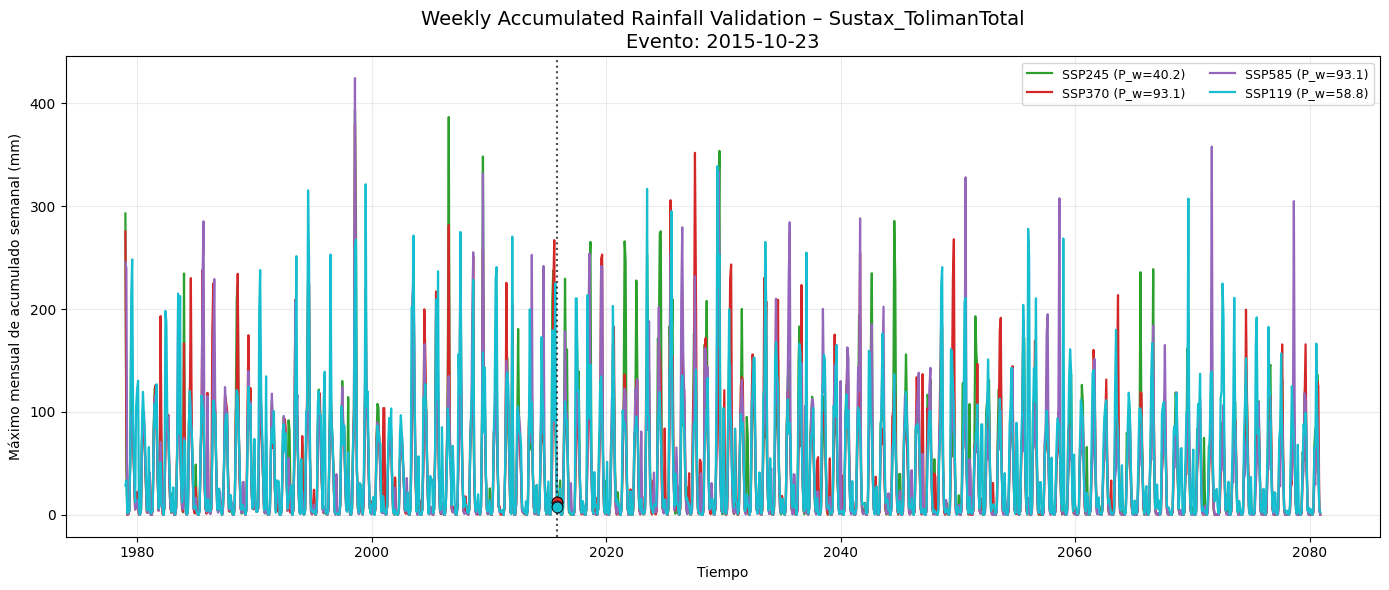

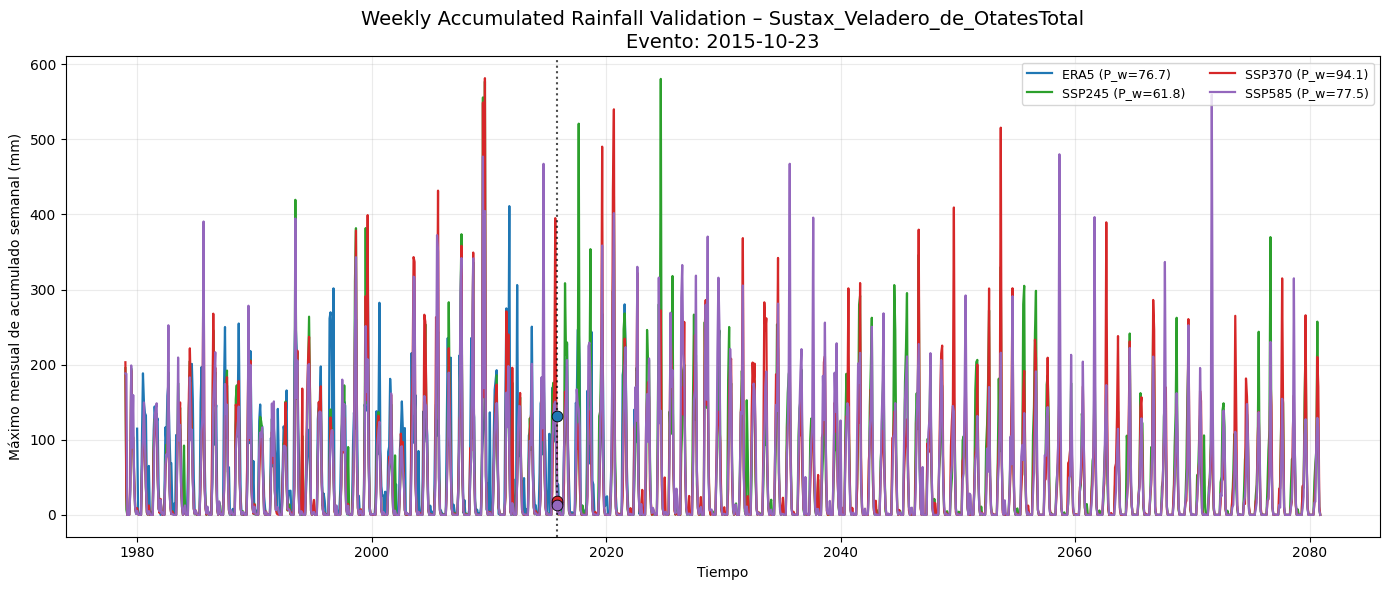

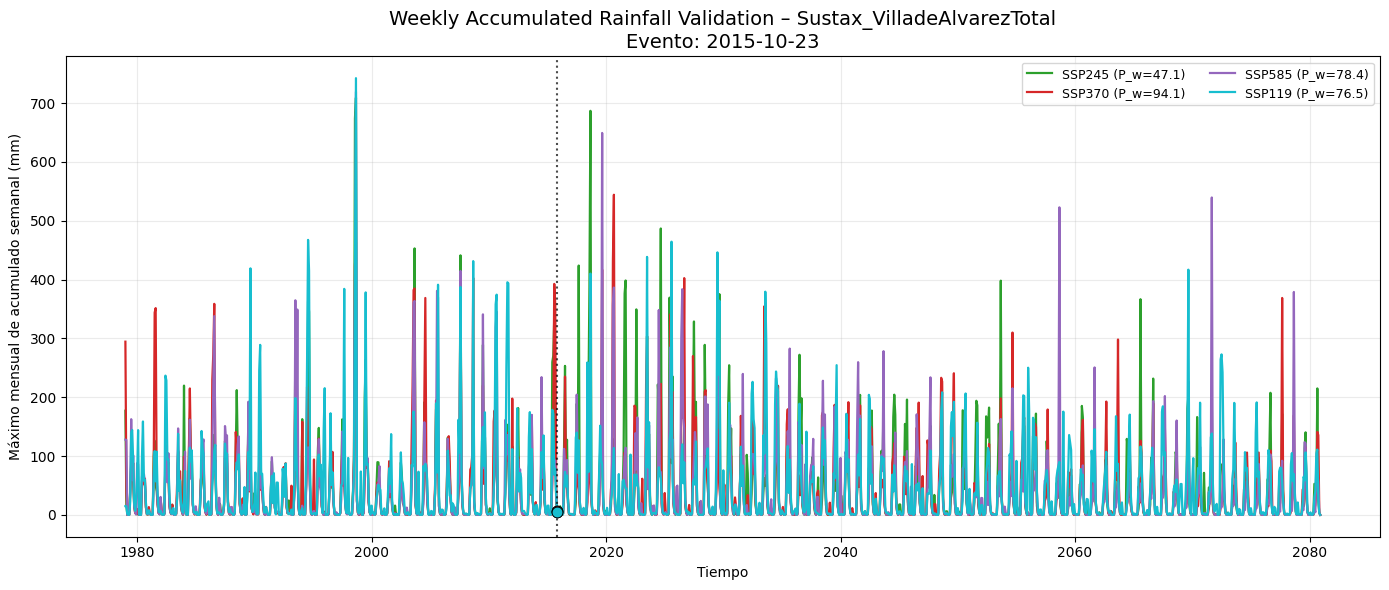

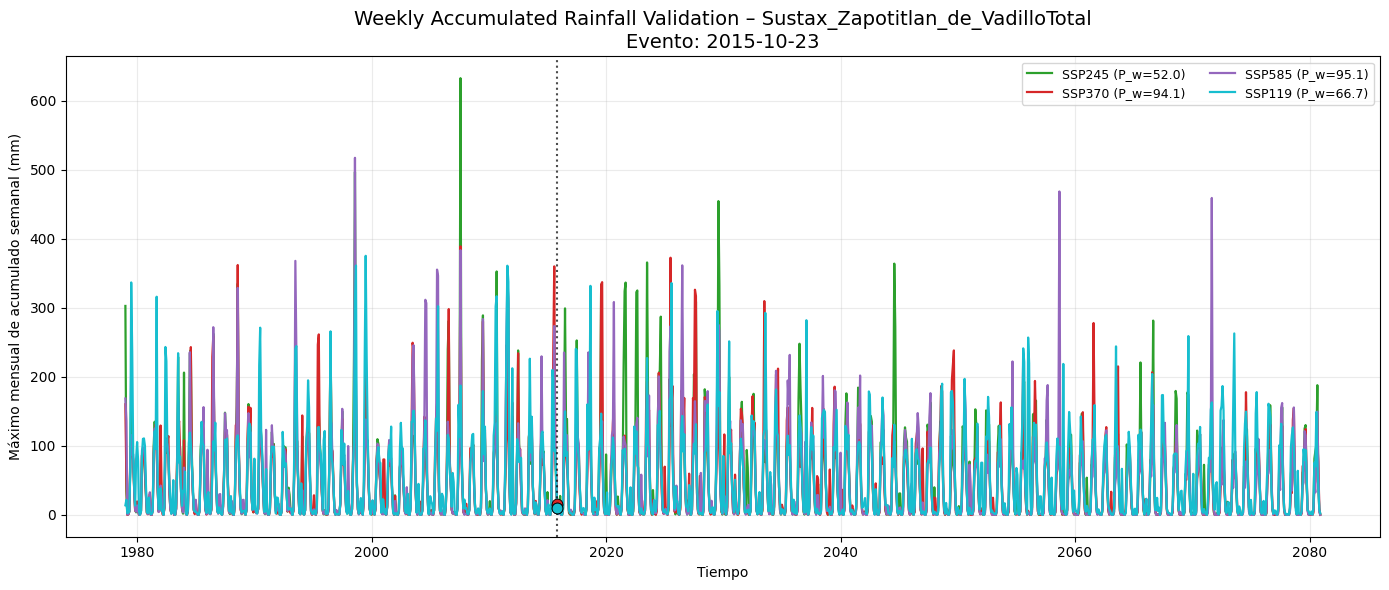

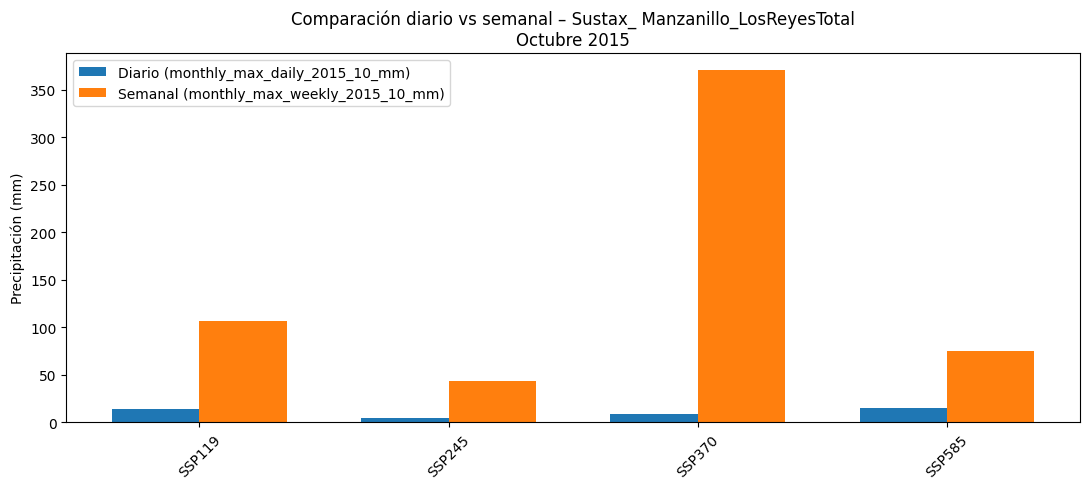

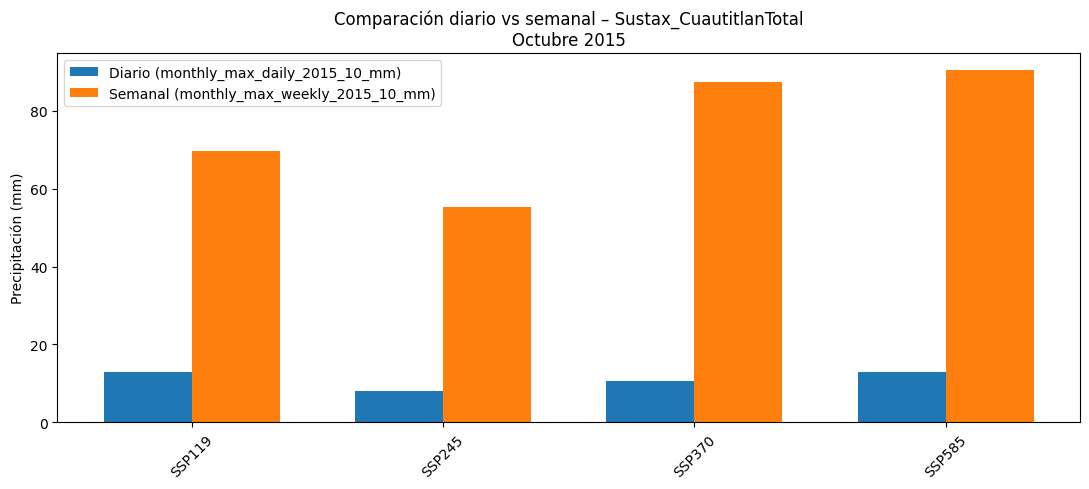

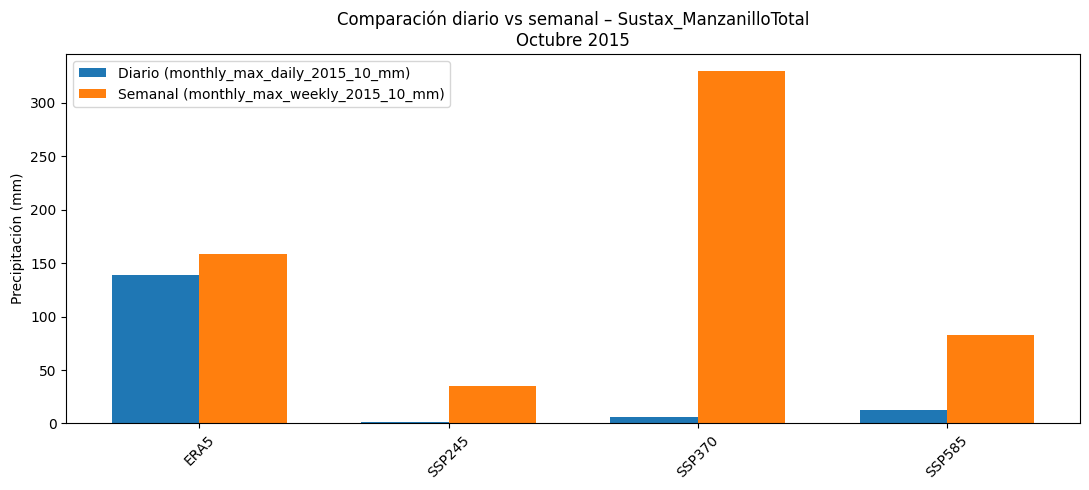

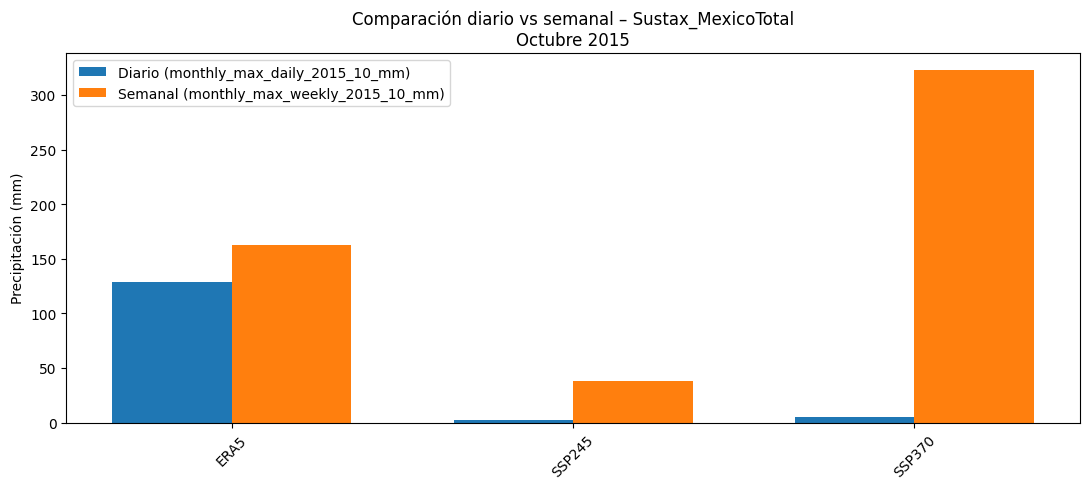

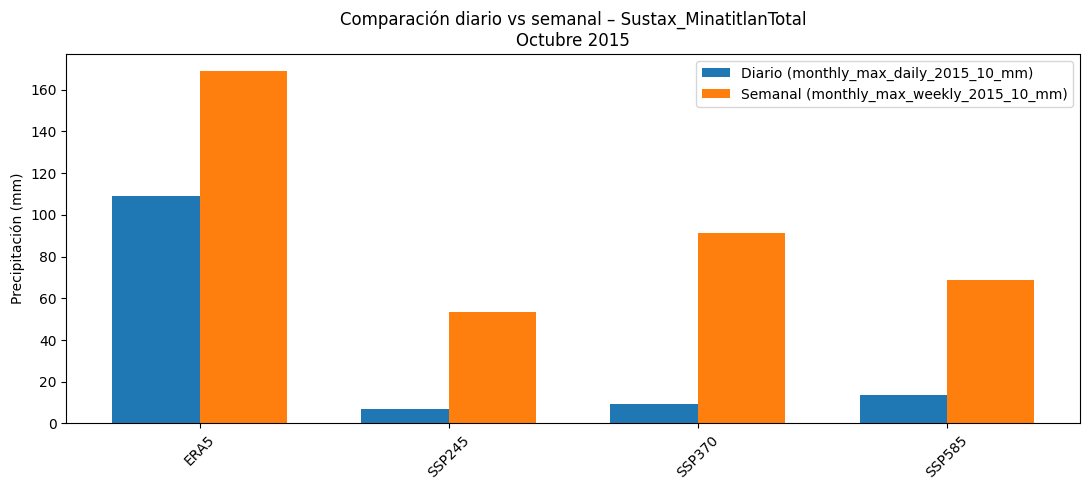

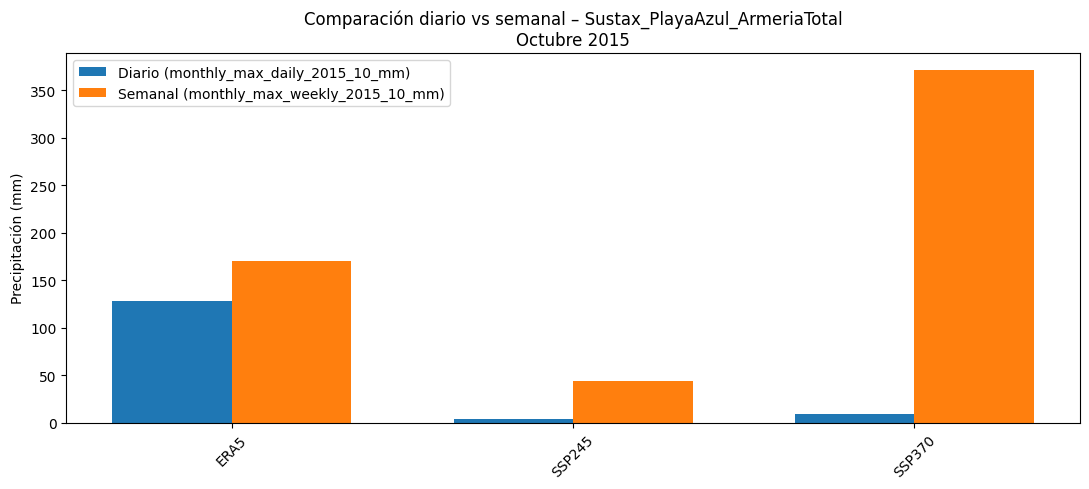

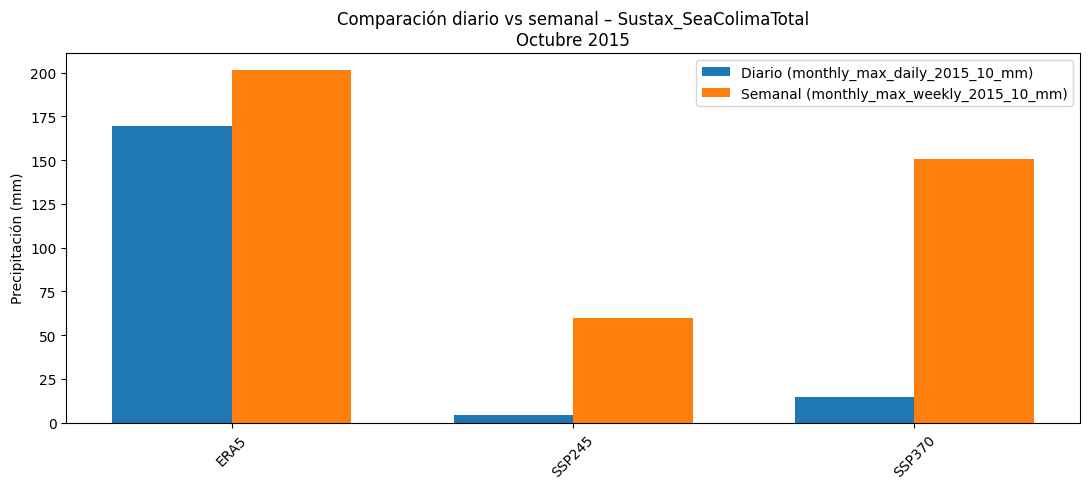

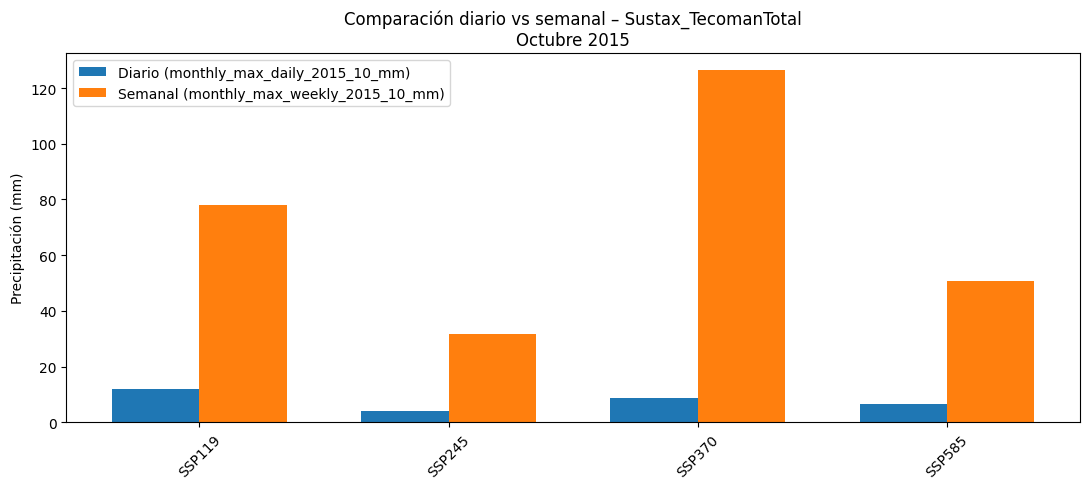

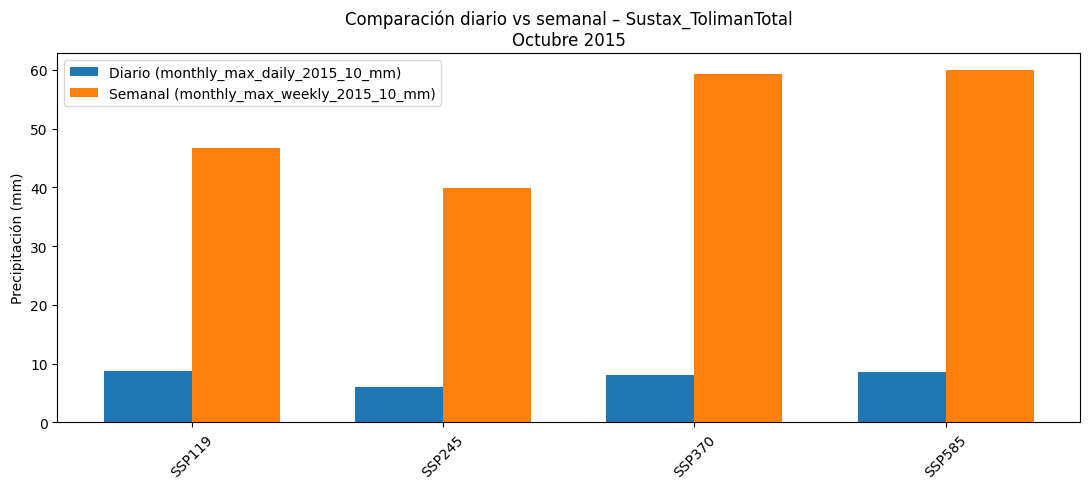

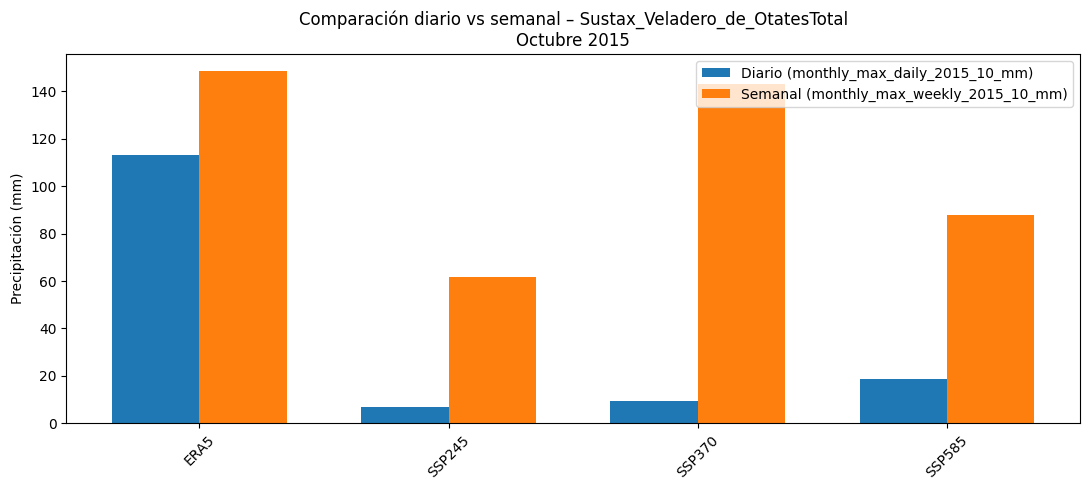

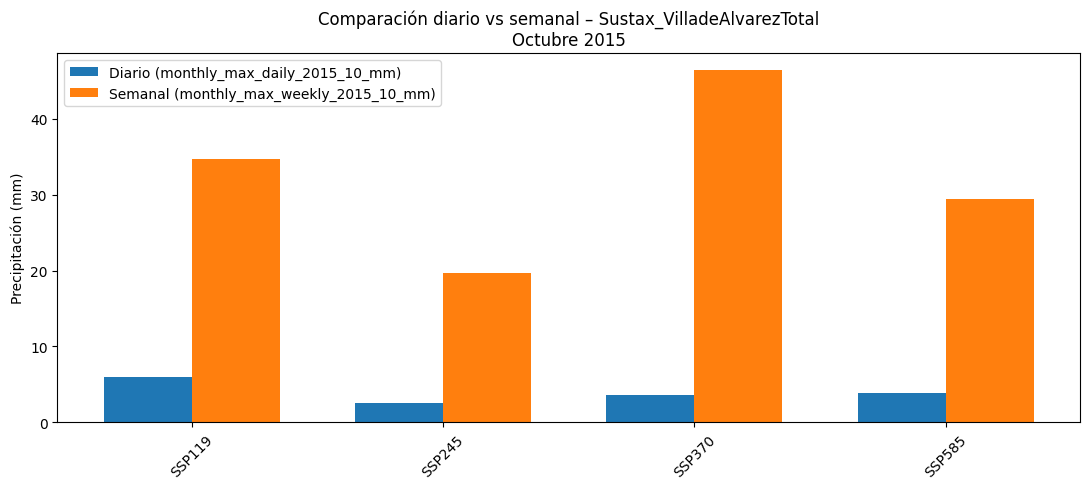

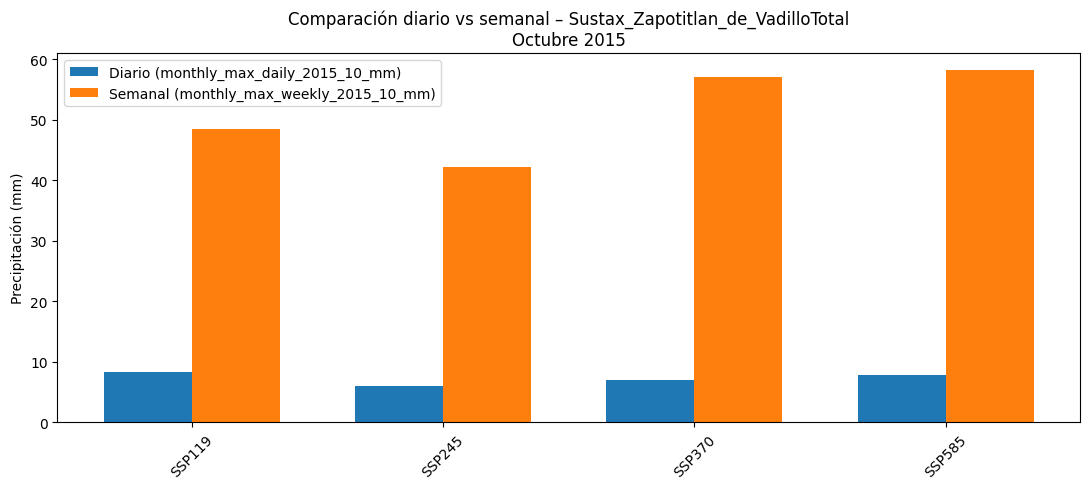

Figuras guardadas en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B
Resumen semanal: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B/PHASE_B_figures_summary.csv
Resumen comparación: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B/PHASE_B_daily_vs_weekly_summary.csv


,sustax_total,col_daily_used,col_weekly_used,n_scenarios,comparison_figure_file
0,Sustax_ Manzanillo_LosReyesTotal,monthly_max_daily_2015_10_mm,monthly_max_weekly_2015_10_mm,4,/content/drive/MyDrive/Doctorado /Probabilidad...
1,Sustax_CuautitlanTotal,monthly_max_daily_2015_10_mm,monthly_max_weekly_2015_10_mm,4,/content/drive/MyDrive/Doctorado /Probabilidad...
2,Sustax_ManzanilloTotal,monthly_max_daily_2015_10_mm,monthly_max_weekly_2015_10_mm,4,/content/drive/MyDrive/Doctorado /Probabilidad...
3,Sustax_MexicoTotal,monthly_max_daily_2015_10_mm,monthly_max_weekly_2015_10_mm,3,/content/drive/MyDrive/Doctorado /Probabilidad...
4,Sustax_MinatitlanTotal,monthly_max_daily_2015_10_mm,monthly_max_weekly_2015_10_mm,4,/content/drive/MyDrive/Doctorado /Probabilidad...


In [12]:
summary_rows = []
comparison_rows = []

for sustax_total in sorted(df_combined["sustax_total"].dropna().unique()):

    chosen_scenarios = choose_scenarios_for_plot(sustax_total)
    if not chosen_scenarios:
        print(f"⚠️ Sin escenarios para {sustax_total}")
        continue

    point_week = df_weekly[df_weekly["sustax_total"] == sustax_total].copy()

    fig_created = False
    plt.figure(figsize=(14, 6))

    for sc in chosen_scenarios:
        fp = get_scenario_file(sustax_total, sc, BYSCEN_TOTAL_FOLDER)
        if fp is None:
            print(f"⚠️ Archivo no encontrado para {sustax_total} - {sc}")
            continue

        try:
            df_sc = pd.read_csv(fp)
            pp_col = pick_precip_col(df_sc)
            df_roll, monthly_week = compute_monthly_max_weekly(df_sc, value_col=pp_col)
        except Exception as e:
            print(f"⚠️ Error en {sustax_total} - {sc}: {e}")
            continue

        if monthly_week.empty:
            print(f"⚠️ monthly_week vacío para {sustax_total} - {sc}")
            continue

        color = SCENARIO_COLORS.get(sc, None)

        sub_info = point_week[point_week["scenario"] == sc].copy()

        pct_week = np.nan
        event_week = np.nan

        if not sub_info.empty:
            if "october_percentile_weekly_max" in sub_info.columns:
                pct_week = pd.to_numeric(sub_info["october_percentile_weekly_max"], errors="coerce").iloc[0]
            if "event_value_weekly_7d_mm" in sub_info.columns:
                event_week = pd.to_numeric(sub_info["event_value_weekly_7d_mm"], errors="coerce").iloc[0]

        label = sc
        if pd.notna(pct_week):
            label = f"{sc} (P_w={pct_week:.1f})"

        plt.plot(
            monthly_week["year_month"],
            monthly_week["monthly_max_weekly_mm"],
            linewidth=1.6,
            color=color,
            label=label
        )
        fig_created = True

        if pd.notna(event_week):
            plt.scatter(
                [TARGET_DT],
                [event_week],
                s=60,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=5
            )

    if fig_created:
        plt.axvline(TARGET_DT, linestyle=":", color="black", linewidth=1.5, alpha=0.7)
        plt.title(
            f"Weekly Accumulated Rainfall Validation – {sustax_total}\nEvento: {TARGET_DATE}",
            fontsize=14
        )
        plt.xlabel("Tiempo")
        plt.ylabel("Máximo mensual de acumulado semanal (mm)")
        plt.grid(True, alpha=0.25)
        plt.legend(loc="upper right", fontsize=9, ncol=2)
        plt.tight_layout()

        out_fp = os.path.join(OUT_FIG_FOLDER, f"{sustax_total}__weekly_validation.png")
        plt.savefig(out_fp, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        summary_rows.append({
            "sustax_total": sustax_total,
            "scenarios_plotted": " | ".join(chosen_scenarios),
            "weekly_figure_file": out_fp
        })
    else:
        plt.close()
        print(f"⚠️ No se generó figura weekly_validation para {sustax_total}")

for sustax_total in sorted(df_combined["sustax_total"].dropna().unique()):

    point_info = df_combined[df_combined["sustax_total"] == sustax_total].copy()
    chosen_scenarios = choose_scenarios_for_plot(sustax_total)
    point_info = point_info[point_info["scenario"].isin(chosen_scenarios)].copy()

    if point_info.empty:
        continue

    col_daily = None
    col_weekly = None

    possible_daily = [
        "monthly_max_daily_2015_10_mm",
        "monthly_max_2015_10_mm",
        "scenario_monthly_max_mm"
    ]

    possible_weekly = [
        "monthly_max_weekly_2015_10_mm",
        "event_value_weekly_7d_mm"
    ]

    for c in possible_daily:
        if c in point_info.columns:
            col_daily = c
            break

    for c in possible_weekly:
        if c in point_info.columns:
            col_weekly = c
            break

    if col_daily is None or col_weekly is None:
        print(f"⚠️ Columnas no encontradas para {sustax_total}")
        print("Disponibles:", point_info.columns.tolist())
        continue

    point_info[col_daily] = pd.to_numeric(point_info[col_daily], errors="coerce")
    point_info[col_weekly] = pd.to_numeric(point_info[col_weekly], errors="coerce")

    x = np.arange(len(point_info))
    width = 0.35

    plt.figure(figsize=(11, 5))

    plt.bar(
        x - width / 2,
        point_info[col_daily],
        width=width,
        label=f"Diario ({col_daily})"
    )

    plt.bar(
        x + width / 2,
        point_info[col_weekly],
        width=width,
        label=f"Semanal ({col_weekly})"
    )

    plt.xticks(x, point_info["scenario"], rotation=45)
    plt.ylabel("Precipitación (mm)")
    plt.title(f"Comparación diario vs semanal – {sustax_total}\nOctubre 2015")
    plt.legend()
    plt.tight_layout()

    out_fp = os.path.join(OUT_FIG_FOLDER, f"{sustax_total}__daily_vs_weekly.png")
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    comparison_rows.append({
        "sustax_total": sustax_total,
        "col_daily_used": col_daily,
        "col_weekly_used": col_weekly,
        "n_scenarios": len(point_info),
        "comparison_figure_file": out_fp
    })

df_fig_summary = pd.DataFrame(summary_rows)
df_compare_summary = pd.DataFrame(comparison_rows)

summary_fp = os.path.join(OUT_FIG_FOLDER, "PHASE_B_figures_summary.csv")
compare_fp = os.path.join(OUT_FIG_FOLDER, "PHASE_B_daily_vs_weekly_summary.csv")

df_fig_summary.to_csv(summary_fp, index=False)
df_compare_summary.to_csv(compare_fp, index=False)

print("Figuras guardadas en:", OUT_FIG_FOLDER)
print("Resumen semanal:", summary_fp)
print("Resumen comparación:", compare_fp)

display(df_compare_summary.head())

# **Heatmaps generales y corregidos**

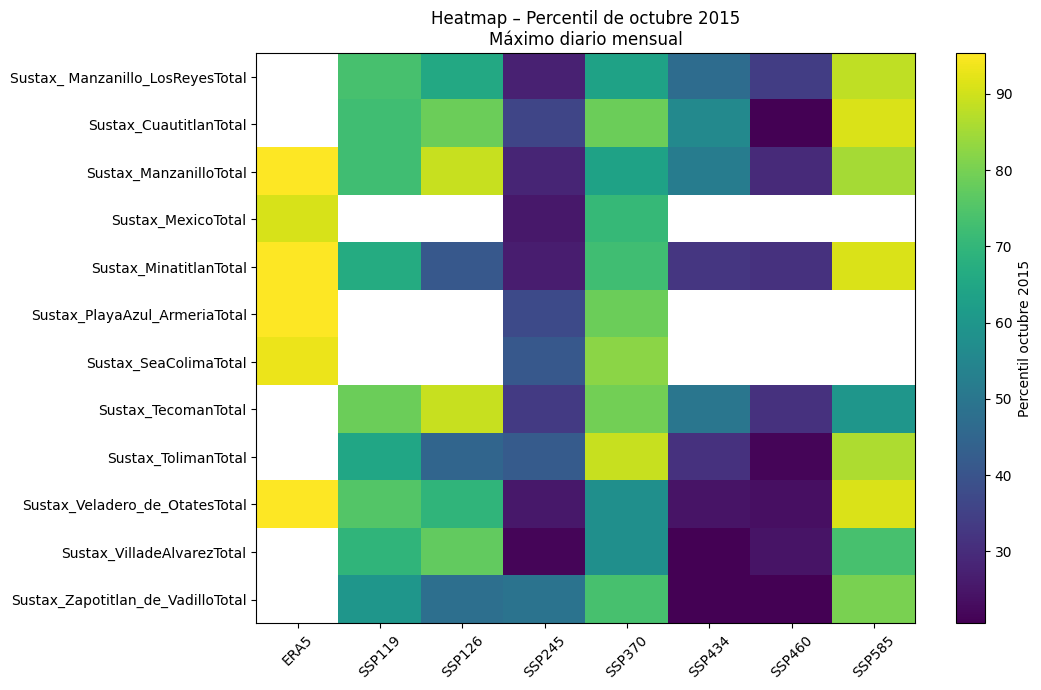

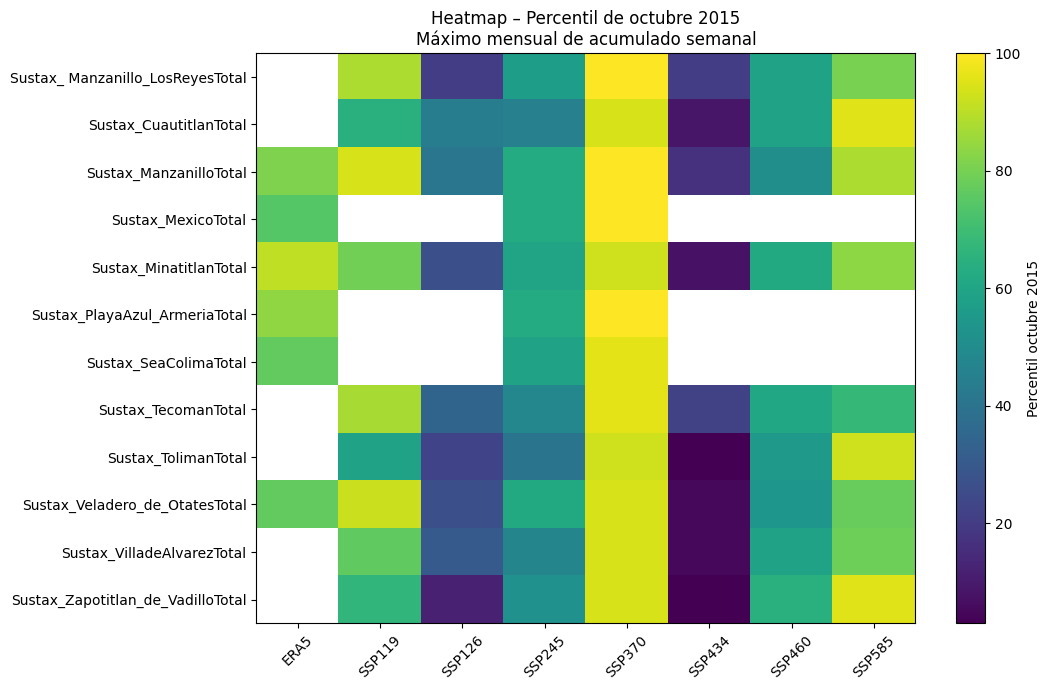

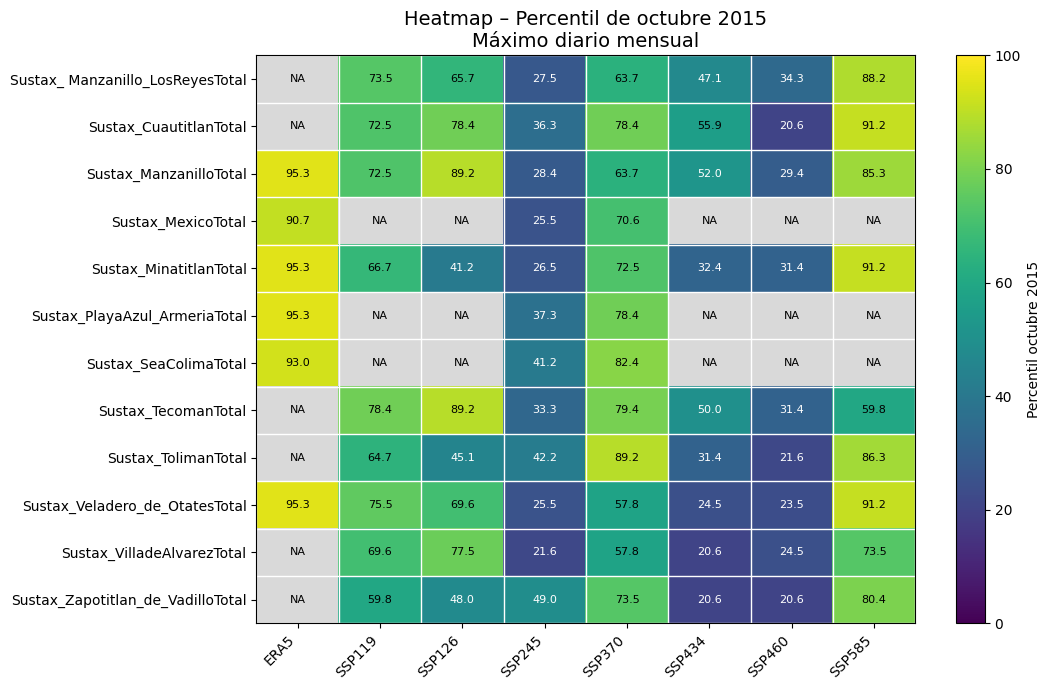

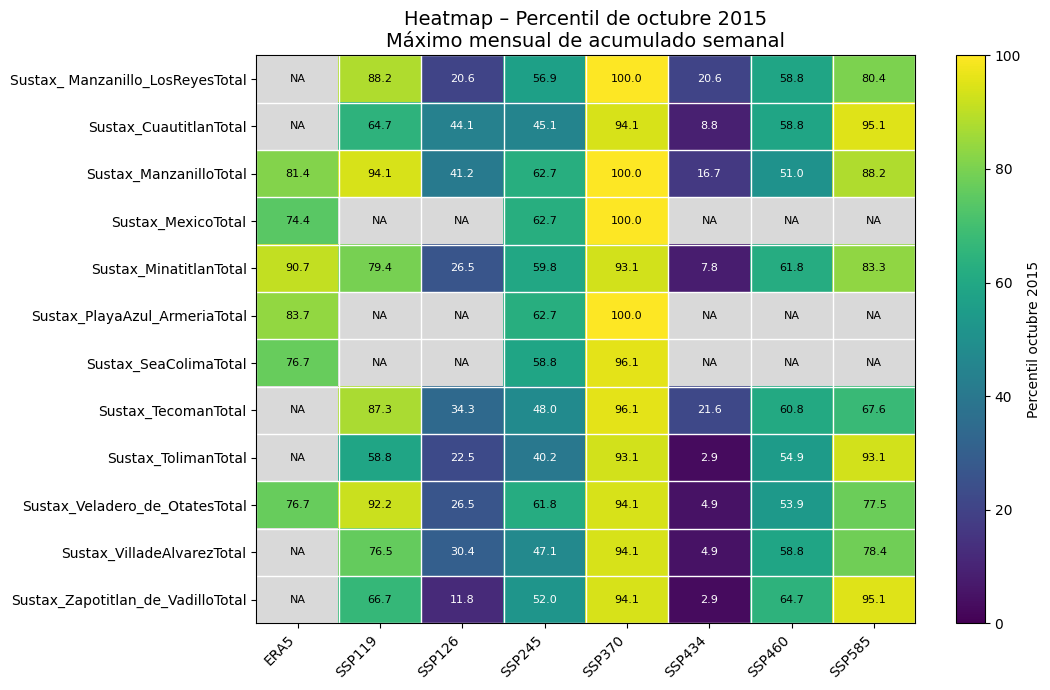

Heatmaps generales guardados.


,sustax_total,scenario,monthly_max_daily_2015_10_mm,october_percentile_daily_max,october_rank_daily_max,n_october_years_daily_max
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,13.985031,73.529412,75,102
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,6.900040,65.686275,67,102
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,4.003961,27.450980,28,102
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,9.115235,63.725490,65,102
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,22.831460,47.058824,48,102


In [10]:
heat_daily = df_monthly_daily.pivot(index="sustax_total", columns="scenario", values="october_percentile_daily_max")

plt.figure(figsize=(11, 7))
plt.imshow(heat_daily, aspect="auto")
plt.colorbar(label="Percentil octubre 2015")
plt.xticks(range(len(heat_daily.columns)), heat_daily.columns, rotation=45)
plt.yticks(range(len(heat_daily.index)), heat_daily.index)
plt.title("Heatmap – Percentil de octubre 2015\nMáximo diario mensual")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_daily.png"), dpi=300)
plt.show()
plt.close()

heat_weekly = df_weekly.pivot(index="sustax_total", columns="scenario", values="october_percentile_weekly_max")

plt.figure(figsize=(11, 7))
plt.imshow(heat_weekly, aspect="auto")
plt.colorbar(label="Percentil octubre 2015")
plt.xticks(range(len(heat_weekly.columns)), heat_weekly.columns, rotation=45)
plt.yticks(range(len(heat_weekly.index)), heat_weekly.index)
plt.title("Heatmap – Percentil de octubre 2015\nMáximo mensual de acumulado semanal")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_weekly.png"), dpi=300)
plt.show()
plt.close()

def plot_percentile_heatmap(df, index_col, columns_col, values_col, title, out_fp,
                            vmin=0, vmax=100, cmap_name="viridis"):

    heat = df.pivot(index=index_col, columns=columns_col, values=values_col)

    desired_cols = ["ERA5", "SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]
    heat = heat.reindex(columns=[c for c in desired_cols if c in heat.columns])

    data = heat.values.astype(float)

    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad(color="#d9d9d9")

    fig, ax = plt.subplots(figsize=(11, 7))

    im = ax.imshow(
        data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_xticklabels(heat.columns, rotation=45, ha="right")
    ax.set_yticklabels(heat.index)

    ax.set_xticks(np.arange(-.5, len(heat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(heat.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if np.isnan(val):
                ax.text(j, i, "NA", ha="center", va="center", fontsize=8, color="black")
            else:
                txt_color = "white" if val < 55 else "black"
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color=txt_color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Percentil octubre 2015")

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_percentile_heatmap(
    df=df_monthly_daily,
    index_col="sustax_total",
    columns_col="scenario",
    values_col="october_percentile_daily_max",
    title="Heatmap – Percentil de octubre 2015\nMáximo diario mensual",
    out_fp=os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_daily_FIXED.png")
)

plot_percentile_heatmap(
    df=df_weekly,
    index_col="sustax_total",
    columns_col="scenario",
    values_col="october_percentile_weekly_max",
    title="Heatmap – Percentil de octubre 2015\nMáximo mensual de acumulado semanal",
    out_fp=os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_weekly_FIXED.png")
)

print("Heatmaps generales guardados.")
display(df_monthly_daily.head())

# **Heatmaps SSP-only**

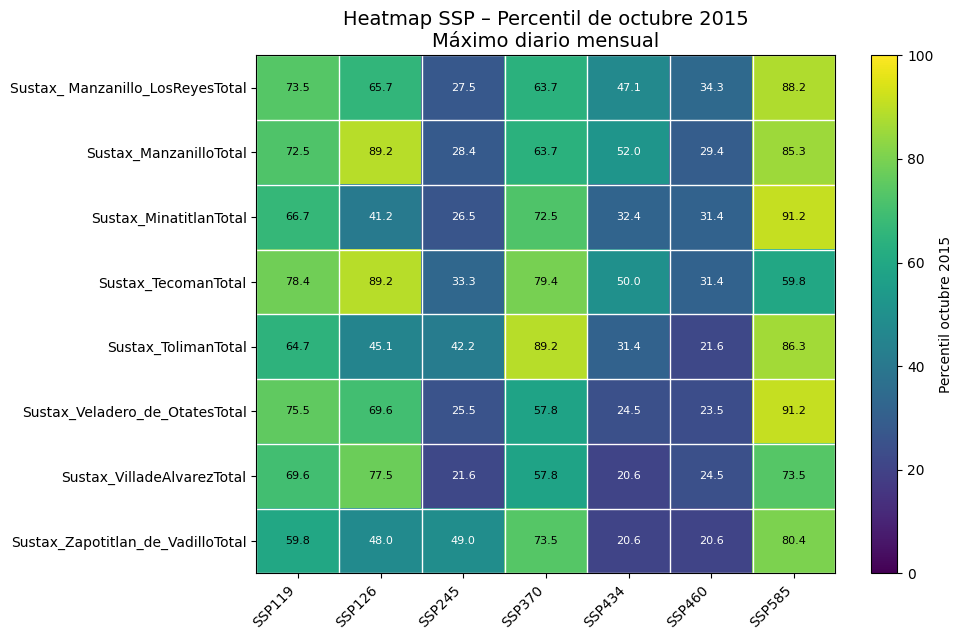

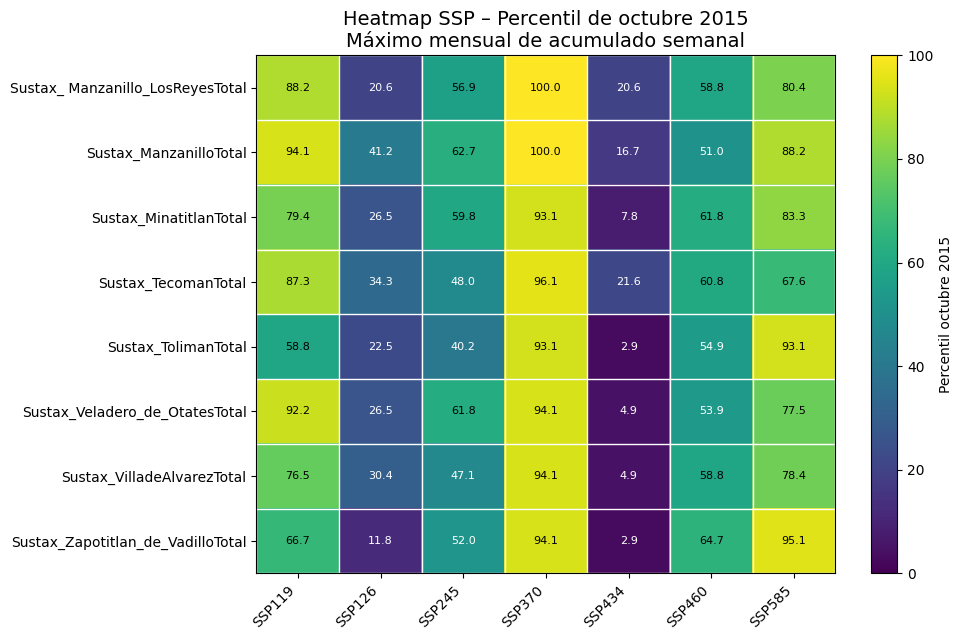

Heatmaps SSP guardados en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_B_SCENARIOS/FIGURES_PHASE_B_SSP_ONLY


,sustax_total,scenario,event_value_weekly_7d_mm,monthly_max_weekly_2015_10_mm,october_percentile_weekly_max,october_rank_weekly_max,n_october_years_weekly_max
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,4.617921,106.399573,88.235294,90,102
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,9.837805,29.988042,20.588235,21,102
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,7.462686,43.745216,56.862745,58,102
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,9.453609,370.535151,100.000000,102,102
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,18.270972,58.979454,20.588235,21,102


In [11]:
df_monthly_daily_ssp = df_monthly_daily[
    (df_monthly_daily["sustax_total"].isin(POINTS_TO_USE)) &
    (df_monthly_daily["scenario"].isin(SSP_LIST))
].copy()

df_weekly_ssp = df_weekly[
    (df_weekly["sustax_total"].isin(POINTS_TO_USE)) &
    (df_weekly["scenario"].isin(SSP_LIST))
].copy()

def plot_percentile_heatmap_ssp(df, value_col, title, out_fp):
    heat = df.pivot(index="sustax_total", columns="scenario", values=value_col)
    heat = heat.reindex(index=POINTS_TO_USE, columns=SSP_LIST)

    data = heat.values.astype(float)

    cmap = mpl.colormaps["viridis"].copy()
    cmap.set_bad(color="#d9d9d9")

    fig, ax = plt.subplots(figsize=(10, 6.5))

    im = ax.imshow(
        data,
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=100
    )

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_xticklabels(heat.columns, rotation=45, ha="right")
    ax.set_yticklabels(heat.index)

    ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if np.isnan(val):
                ax.text(j, i, "NA", ha="center", va="center", fontsize=8, color="black")
            else:
                txt_color = "white" if val < 55 else "black"
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color=txt_color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Percentil octubre 2015")

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_percentile_heatmap_ssp(
    df=df_monthly_daily_ssp,
    value_col="october_percentile_daily_max",
    title="Heatmap SSP – Percentil de octubre 2015\nMáximo diario mensual",
    out_fp=os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_daily.png")
)

plot_percentile_heatmap_ssp(
    df=df_weekly_ssp,
    value_col="october_percentile_weekly_max",
    title="Heatmap SSP – Percentil de octubre 2015\nMáximo mensual de acumulado semanal",
    out_fp=os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_weekly.png")
)

print("Heatmaps SSP guardados en:", OUT_FIG_FOLDER_SSP)
display(df_weekly_ssp.head())